In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from utils import eda_utils
"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [36]:
data = pd.read_csv("../dataset/Spotify_crudo.csv")

df = data.copy()

In [37]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [39]:
df = df.drop(columns=["Unnamed: 0", "track_id"])

In [40]:
outliers_iqr = eda_utils.detectar_outliers_iqr(df)
outliers_3sig = eda_utils.detectar_outliers_3sigmas(df)

In [41]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
df.describe(include="object") 

,artists,album_name,track_name,track_genre
count,113999,113999,113999,114000
unique,31437,46589,73608,114
top,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,279,195,151,1000


In [42]:
print("***Detección de outliers con método 3 sigmas***", end="\n" + ("-"*40) + "\n")
for col, info in outliers_3sig.items():
    print(f"Columna: {col}")
    print(f"Asimetría (skew): {info['skew']:.3f}")
    print(f"Cantidad de outliers: {info['cantidad_outliers']}")
    print(f"Límite inferior: {info['limite_inferior']:.3f}")
    print(f"Límite superior: {info['limite_superior']:.3f}")
    print("-"*40)

***Detección de outliers con método 3 sigmas***
----------------------------------------
Columna: popularity
Asimetría (skew): 0.046
Cantidad de outliers: 0
Límite inferior: -33.677
Límite superior: 100.154
----------------------------------------
Columna: duration_ms
Asimetría (skew): 11.195
Cantidad de outliers: 946
Límite inferior: -93863.985
Límite superior: 549922.291
----------------------------------------
Columna: danceability
Asimetría (skew): -0.399
Cantidad de outliers: 157
Límite inferior: 0.046
Límite superior: 1.087
----------------------------------------
Columna: energy
Asimetría (skew): -0.597
Cantidad de outliers: 0
Límite inferior: -0.113
Límite superior: 1.396
----------------------------------------
Columna: key
Asimetría (skew): -0.009
Cantidad de outliers: 0
Límite inferior: -5.371
Límite superior: 15.989
----------------------------------------
Columna: loudness
Asimetría (skew): -2.007
Cantidad de outliers: 2475
Límite inferior: -23.347
Límite superior: 6.829
-

In [43]:
print("***Detección de outliers con método IQR***", end="\n" + ("-"*40) + "\n")
for col, info in outliers_iqr.items():
    print(f"Columna: {col}")
    print(f"Asimetría (skew): {info['skew']:.3f}")
    print(f"Cantidad de outliers: {info['cantidad_outliers']}")
    print(f"Límite inferior: {info['limite_inferior']:.3f}")
    print(f"Límite superior: {info['limite_superior']:.3f}")
    print("-"*40)

***Detección de outliers con método IQR***
----------------------------------------
Columna: popularity
Asimetría (skew): 0.046
Cantidad de outliers: 2
Límite inferior: -32.500
Límite superior: 99.500
----------------------------------------
Columna: duration_ms
Asimetría (skew): 11.195
Cantidad de outliers: 5617
Límite inferior: 42906.000
Límite superior: 392666.000
----------------------------------------
Columna: danceability
Asimetría (skew): -0.399
Cantidad de outliers: 620
Límite inferior: 0.098
Límite superior: 1.053
----------------------------------------
Columna: energy
Asimetría (skew): -0.597
Cantidad de outliers: 0
Límite inferior: -0.101
Límite superior: 1.427
----------------------------------------
Columna: key
Asimetría (skew): -0.009
Cantidad de outliers: 0
Límite inferior: -7.000
Límite superior: 17.000
----------------------------------------
Columna: loudness
Asimetría (skew): -2.007
Cantidad de outliers: 6173
Límite inferior: -17.528
Límite superior: 2.512
-------

In [44]:
df.isna().sum()

artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

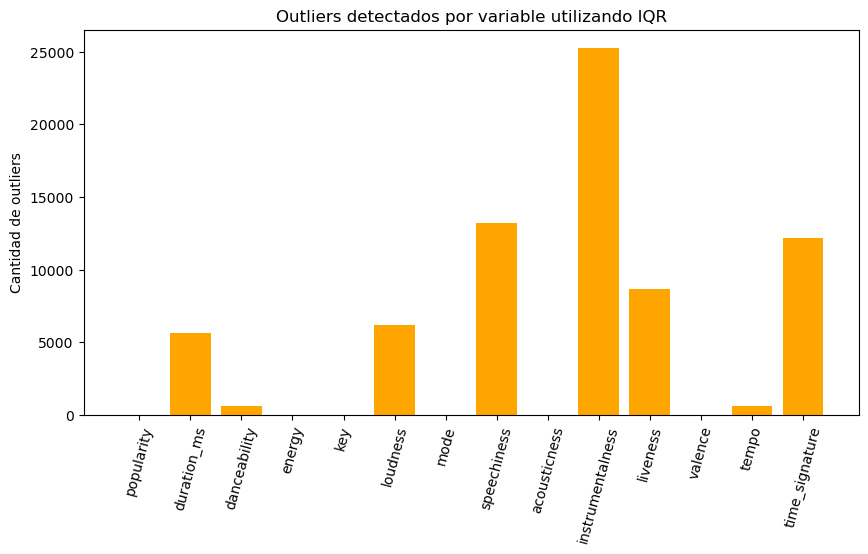

In [ ]:
resultados = eda_utils.detectar_outliers_iqr(df)

outliers = {
    col: datos['cantidad_outliers']
    for col, datos in resultados.items()
}

plt.figure(figsize=(10,5))

plt.bar(
    outliers.keys(),
    outliers.values(),
        color = "orange"
)

plt.xticks(rotation=75)

plt.ylabel("Cantidad de outliers (Unidades)")
plt.title("Outliers detectados por variable utilizando IQR")

plt.show()